<a href="https://colab.research.google.com/github/prakashdhruvmishra/codealpha_tasks/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- First 5 Rows ---
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

--- Missing Values ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


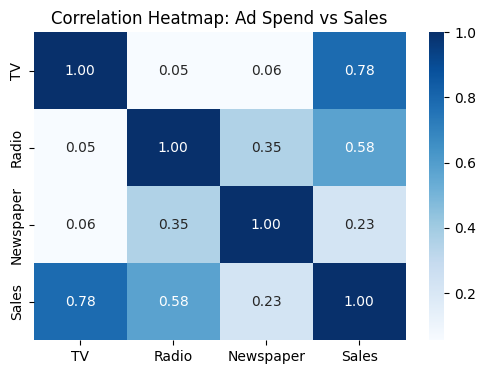

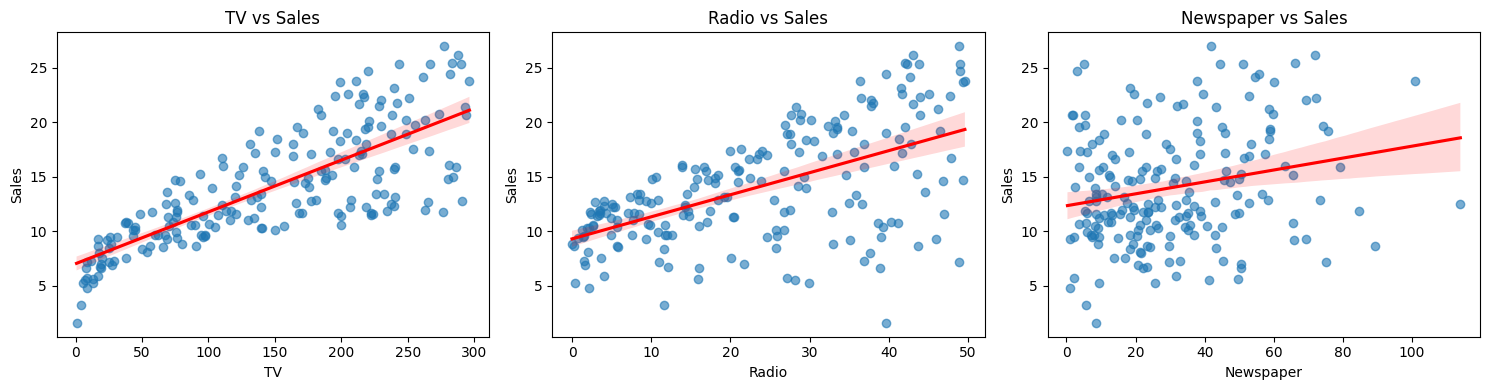


Model R² Score: 0.8994 (89.94% Variance Explained)
Mean Absolute Error (MAE): 1.46
Root Mean Squared Error (RMSE): 1.78

--- Advertising Channel Impact ---
           Impact Coefficient
TV                   0.044730
Radio                0.189195
Newspaper            0.002761
Base Intercept: 2.98


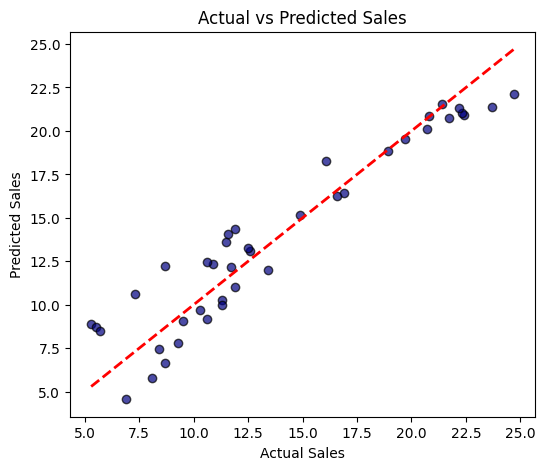


Custom Input Spend ($k): {'TV': 150.0, 'Radio': 30.0, 'Newspaper': 20.0}
Predicted Sales Volume: 15.42 units


In [1]:
# ==========================================
# TASK 4: Sales Prediction using Python
# Repository: codealpha_tasks
# File Name: Sales_Prediction.ipynb
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load Dataset
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# 2. Exploratory Data Analysis (EDA)
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Heatmap: Ad Spend vs Sales")
plt.show()

# Scatter Plots with Trendline
plt.figure(figsize=(15, 4))
channels = ['TV', 'Radio', 'Newspaper']
for idx, channel in enumerate(channels, 1):
    plt.subplot(1, 3, idx)
    sns.regplot(
        x=df[channel],
        y=df['Sales'],
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red'},
    )
    plt.title(f"{channel} vs Sales")
plt.tight_layout()
plt.show()

# 3. Train-Test Split (80% Train, 20% Test)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Model Training (Multiple Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Model Evaluation
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n==========================================")
print(f"Model R² Score: {r2:.4f} ({r2 * 100:.2f}% Variance Explained)")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print("==========================================\n")

# Channel Coefficients
coeff_df = pd.DataFrame(
    model.coef_, X.columns, columns=['Impact Coefficient']
)
print("--- Advertising Channel Impact ---")
print(coeff_df)
print(f"Base Intercept: {model.intercept_:.2f}")

# 6. Actual vs Predicted Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color='navy', edgecolors='k', alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2
)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

# 7. Sample Prediction on Custom Advertising Budget
sample_spend = pd.DataFrame(
    [[150.0, 30.0, 20.0]], columns=['TV', 'Radio', 'Newspaper']
)
predicted_sales = model.predict(sample_spend)
print(f"\nCustom Input Spend ($k): {sample_spend.to_dict(orient='records')[0]}")
print(f"Predicted Sales Volume: {predicted_sales[0]:.2f} units")